In [1]:
load_ext jupyter_black

In [17]:
import pandas as pd
import numpy as np
import os

from scipy.stats import ttest_ind

import seaborn as sns
import matplotlib.pyplot as plt

from data_selection_erasure import (
    evaluation_prism,
    evaluation_cad,
    leace_convos_prism,
    leace_convos_cad,
    neurons_prism,
    neurons_cad,
)

from preprocess_data import get_prism_convos, get_cad_convos

import warnings

warnings.simplefilter("ignore")

In [3]:
evaluation_prism.keys()

dict_keys(['age', 'english', 'recipe', 'race_racism', 'avg_syllables_model', 'realization_user', 'pride_model', 'excitement_model'])

In [4]:
leace_convos_prism.keys()

dict_keys(['pride_model'])

In [5]:
demographics = {
    "prism": [
        "age",
        "gender",
        "employment_status",
        "education",
        "marital_status",
        "english_proficiency",
        "religion",
        "ethnicity",
        "birth_region",
        "reside_region",
        "lm_familiarity",
    ],
    "cad_en": [
        "annotator_age",
        "annotator_gender",
        "annotator_education_level",
        "annotator_political",
        "annotator_ethnicity",
    ],
}

In [6]:
prism_linguistic = pd.read_pickle(f"data/prism_utterances_linguistic.gz")
cad_en_linguistic = pd.read_pickle(f"data/cad_en_utterances_linguistic.gz")

dfs = {"prism": prism_linguistic, "cad_en": cad_en_linguistic}

for dataset in dfs:
    df_linguistic = dfs[dataset]
    for c in ["politeness_user_prompt", "politeness_model_response"]:
        if c in df_linguistic:
            df_linguistic[c] = df_linguistic[c].replace(
                {"impolite": 0, "neutral": 0.5, "polite": 1, "somewhat polite": 0.75}
            )
    df_linguistic = df_linguistic.rename(columns={"gpt_description": "topic"})
    if "model_name" in df_linguistic:
        demographics[dataset] += ["model_name"]
    demographics[dataset] += ["topic"]
    group_cols = ["conversation_id"] + demographics[dataset]
    dfs[dataset] = pd.merge(
        df_linguistic.groupby(group_cols)[
            [
                c
                for c in df_linguistic.columns
                if "_model_response" in c or "_user_prompt" in c
            ]
        ]
        .mean()
        .reset_index(),
        pd.read_pickle(f"data/{dataset}_preprocessed.gz"),
    )
    dfs[dataset] = dfs[dataset].drop(
        columns=[c for c in dfs["prism"].columns if "_x" in c or "_y" in c]
    )

In [7]:
questions = pd.read_pickle("data/questions.gz")
questions_answers = dict(zip(questions.q_id, questions.correct_answer))

age ['middle_age', 'young_old_age'] 80.38 80.36 -0.02488181139586467
TtestResult(statistic=np.float64(0.0374960056098802), pvalue=np.float64(0.9701273020610183), df=np.float64(198.0))


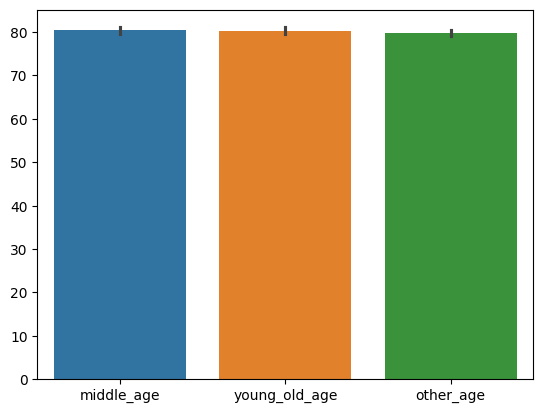

english ['native_english', 'intermediate_english'] 80.3 81.22 1.1457036114570383
TtestResult(statistic=np.float64(-1.7596597063638812), pvalue=np.float64(0.08000985307712942), df=np.float64(198.0))


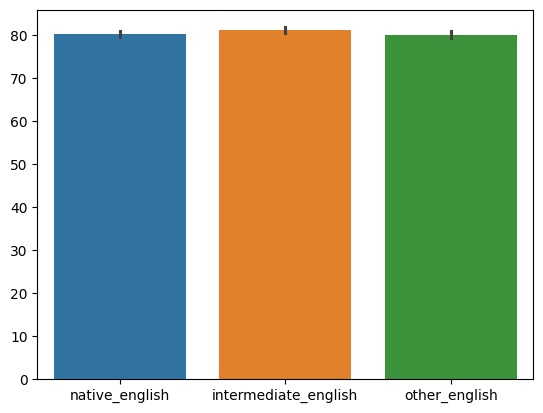

recipe ['recipe', 'non_affected_topic'] 83.0 78.36 -5.590361445783134
TtestResult(statistic=np.float64(9.845074644783066), pvalue=np.float64(7.22273395598168e-19), df=np.float64(198.0))


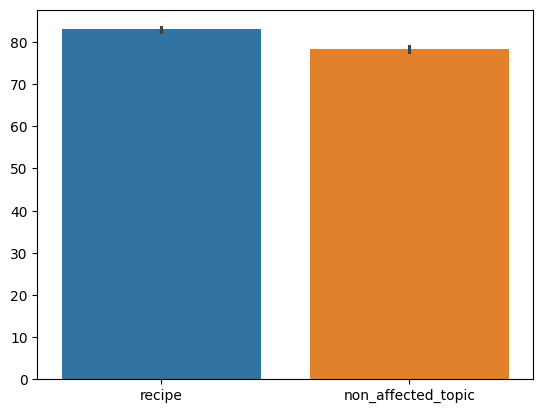

recipe ['recipe', 'non_affected_topic'] 73.54 69.75076923076922 -5.15261187004458
TtestResult(statistic=np.float64(6.396578791424522), pvalue=np.float64(1.1215714355963502e-09), df=np.float64(198.0))


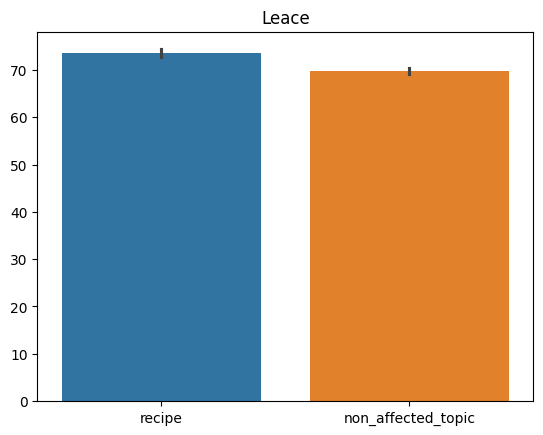

recipe ['recipe', 'non_affected_topic'] 74.9 73.86 -1.388518024032051
TtestResult(statistic=np.float64(2.491445271500116), pvalue=np.float64(0.01354413133318276), df=np.float64(198.0))


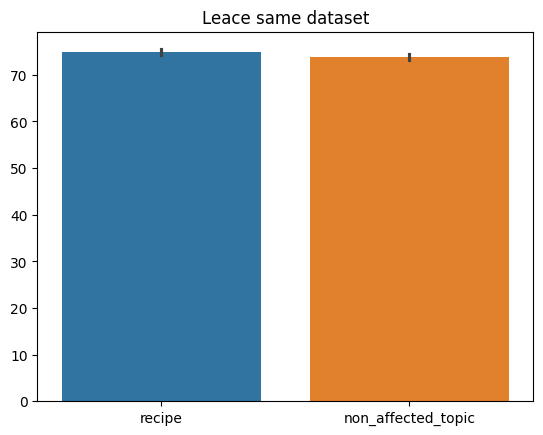

recipe ['recipe', 'non_affected_topic'] nan nan nan
TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))


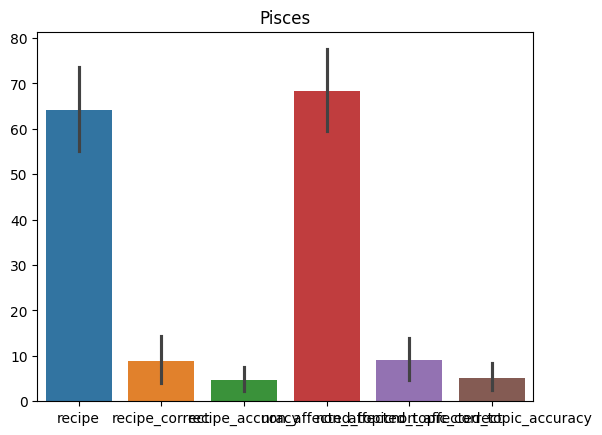

race_racism ['race_racism', 'non_affected_topic'] 82.32323232323232 78.36 -4.814233128834351
TtestResult(statistic=np.float64(7.717362857936455), pvalue=np.float64(5.81477567240922e-13), df=np.float64(197.0))


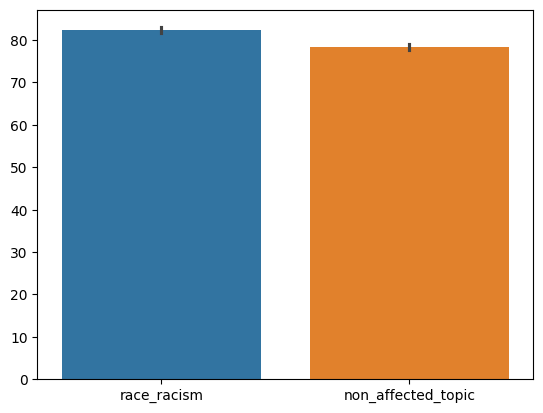

race_racism ['race_racism', 'non_affected_topic'] 72.06060606060606 66.44 -7.799831791421368
TtestResult(statistic=np.float64(7.012379772785624), pvalue=np.float64(3.65784962455204e-11), df=np.float64(197.0))


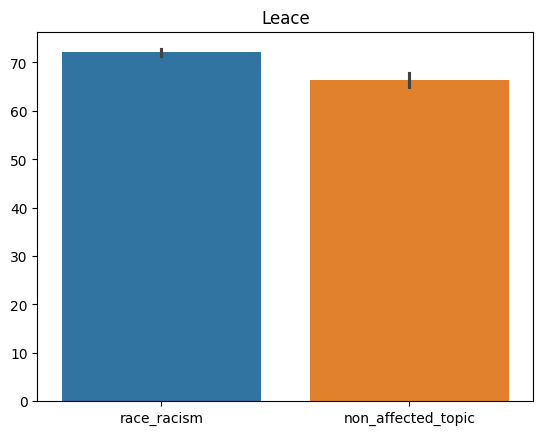

race_racism ['race_racism', 'non_affected_topic'] 81.87878787878788 79.36 -3.0762398223538088
TtestResult(statistic=np.float64(5.601564795337571), pvalue=np.float64(7.078986775086561e-08), df=np.float64(197.0))


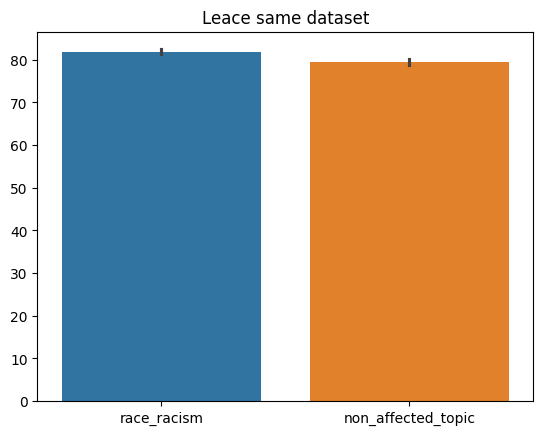

avg_syllables_model ['high_avg_syllables_model', 'low_avg_syllables_model'] 80.46 78.82 -2.0382798906288846
TtestResult(statistic=np.float64(2.8119085671054918), pvalue=np.float64(0.005420415100017603), df=np.float64(198.0))


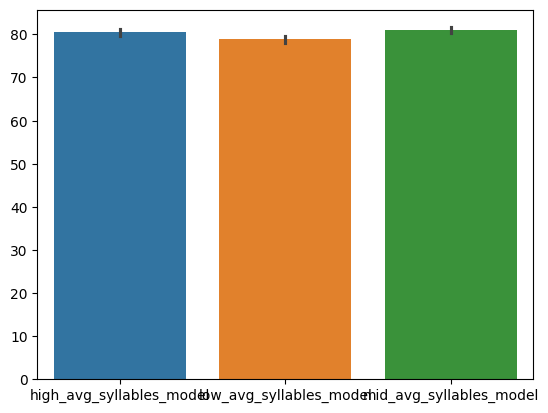

avg_syllables_model ['high_avg_syllables_model', 'low_avg_syllables_model'] 76.38 73.02 -4.399057344854674
TtestResult(statistic=np.float64(7.384664927006254), pvalue=np.float64(4.1556652403694805e-12), df=np.float64(198.0))


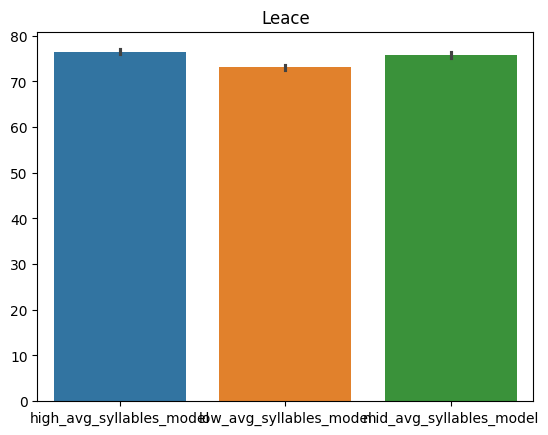

avg_syllables_model ['high_avg_syllables_model', 'low_avg_syllables_model'] 74.34 65.94008592910848 -11.299319438917845
TtestResult(statistic=np.float64(13.45389050290445), pvalue=np.float64(9.884383625631505e-30), df=np.float64(198.0))


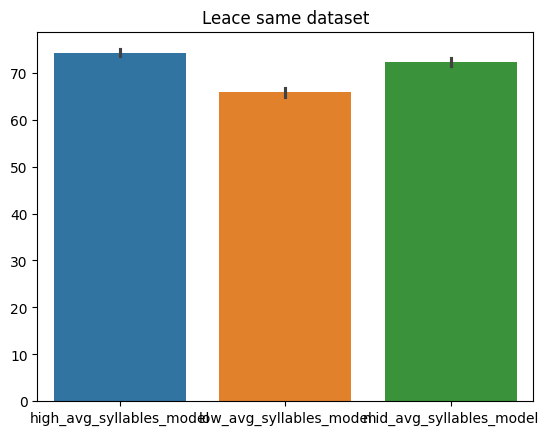

realization_user ['high_realization_user', 'low_realization_user'] 80.26 80.76 0.622975330176925
TtestResult(statistic=np.float64(-0.9382533039923259), pvalue=np.float64(0.34925734727497304), df=np.float64(198.0))


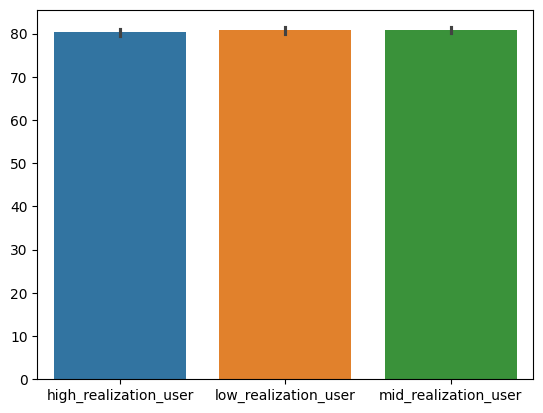

pride_model ['high_pride_model', 'low_pride_model'] 79.34 81.14 2.2687169145449926
TtestResult(statistic=np.float64(-2.819657244183812), pvalue=np.float64(0.005296250608304956), df=np.float64(198.0))


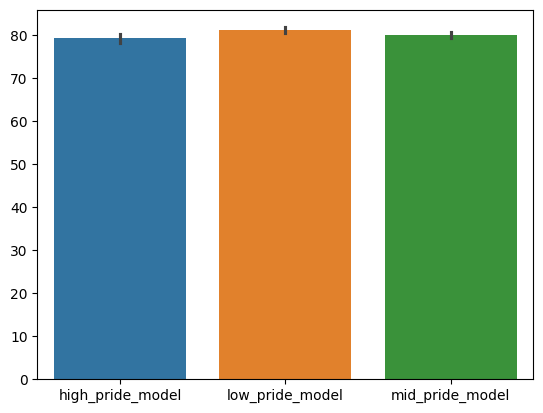

pride_model ['high_pride_model', 'low_pride_model'] 69.47 71.04 2.259968331653962
TtestResult(statistic=np.float64(-2.55957986602158), pvalue=np.float64(0.011226019905356014), df=np.float64(198.0))


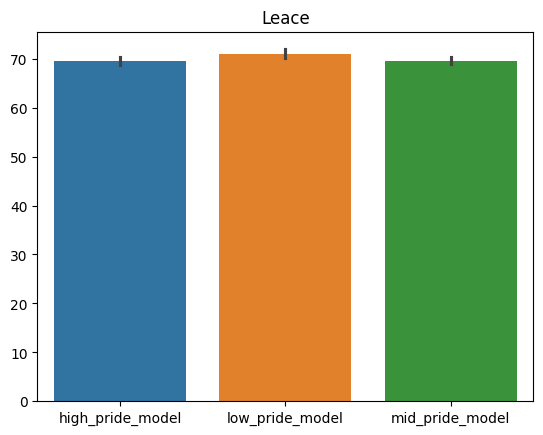

pride_model ['high_pride_model', 'low_pride_model'] 70.41679653679654 73.8 4.804540435797237
TtestResult(statistic=np.float64(-5.238049500239744), pvalue=np.float64(4.132952373854799e-07), df=np.float64(198.0))


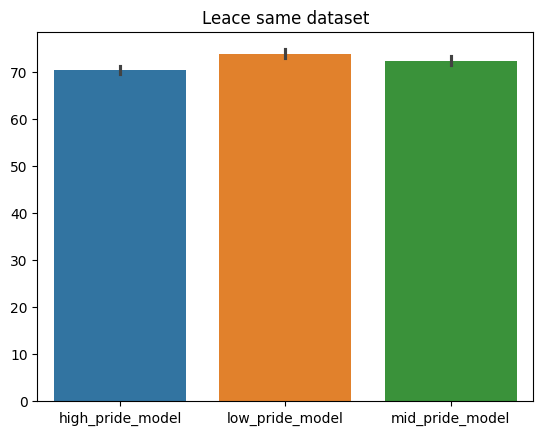

excitement_model ['high_excitement_model', 'low_excitement_model'] 78.24 80.1 2.377300613496932
TtestResult(statistic=np.float64(-2.5651346209287134), pvalue=np.float64(0.011053679886148943), df=np.float64(198.0))


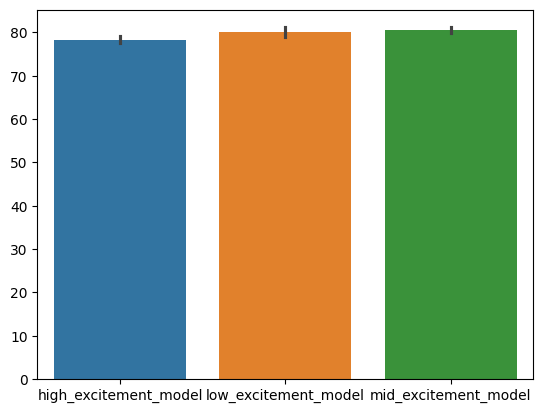

excitement_model ['high_excitement_model', 'low_excitement_model'] 78.08 79.77 2.1644467213114726
TtestResult(statistic=np.float64(-2.854122543581728), pvalue=np.float64(0.004774746241015449), df=np.float64(198.0))


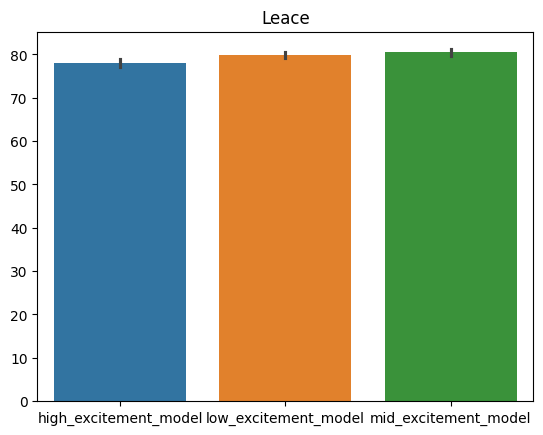

excitement_model ['high_excitement_model', 'low_excitement_model'] 75.54 78.0463601532567 3.3179244814094426
TtestResult(statistic=np.float64(-3.883886867656004), pvalue=np.float64(0.00014007458606858587), df=np.float64(198.0))


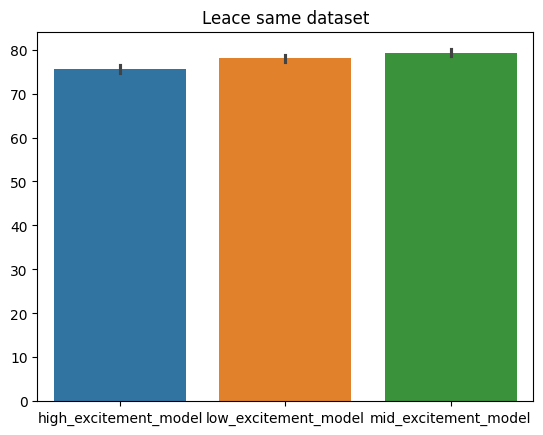

age ['old_age', 'young_age', 'middle_age'] 79.46 78.62 -1.057135665743757
TtestResult(statistic=np.float64(1.6252991533161871), pvalue=np.float64(0.10568948521683068), df=np.float64(198.0))


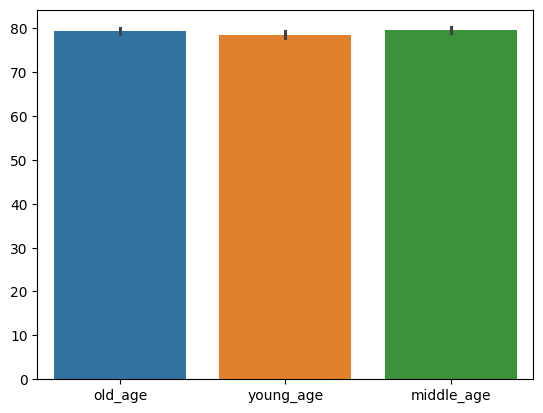

gender ['female', 'male'] 79.5 79.76 0.3270440251572391
TtestResult(statistic=np.float64(-0.504517029316499), pvalue=np.float64(0.6144590947472681), df=np.float64(198.0))


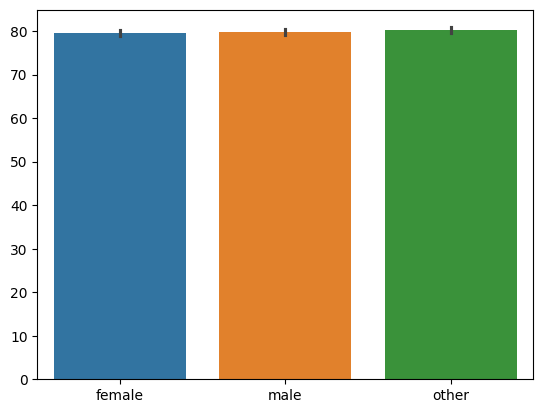

diet ['diet', 'fantasy'] 83.24 73.6304347826087 -11.544407997827118
TtestResult(statistic=np.float64(20.19360044269299), pvalue=np.float64(3.581451663126579e-49), df=np.float64(190.0))


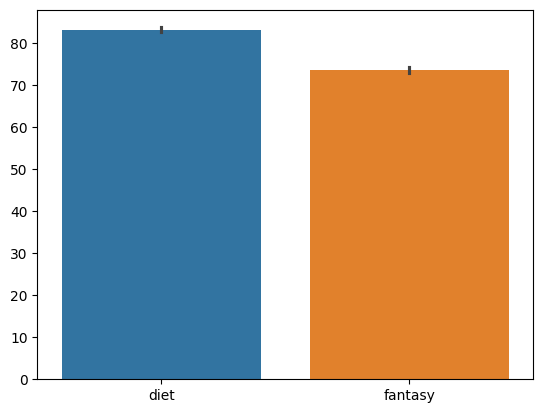

diet ['diet', 'fantasy'] 82.46 73.6086956521739 -10.73405814676945
TtestResult(statistic=np.float64(15.235739729892344), pvalue=np.float64(9.00404657726634e-35), df=np.float64(190.0))


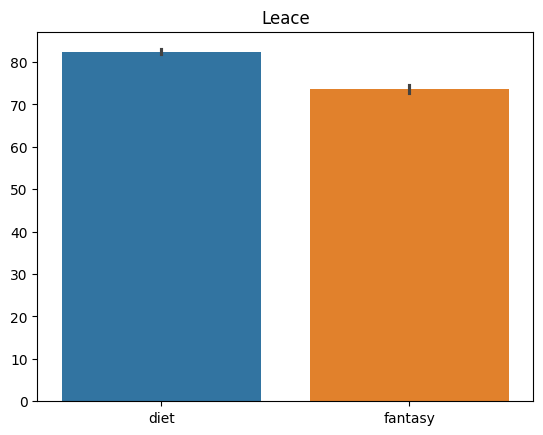

diet ['diet', 'fantasy'] 81.36 58.65217391304348 -27.910307383181564
TtestResult(statistic=np.float64(28.160354849153595), pvalue=np.float64(9.928071088810489e-70), df=np.float64(190.0))


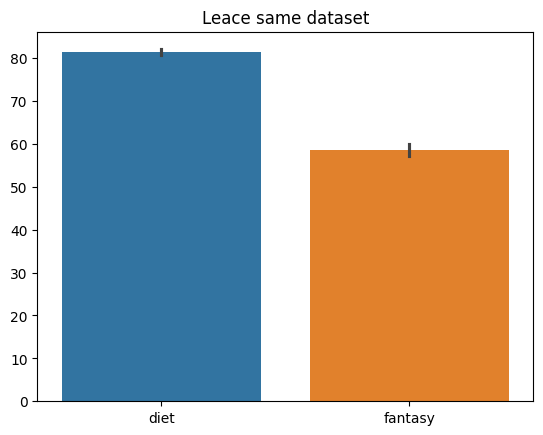

morality ['morality', 'art'] 83.3 76.64 -7.995198079231688
TtestResult(statistic=np.float64(14.664244868710053), pvalue=np.float64(1.903027334161452e-33), df=np.float64(198.0))


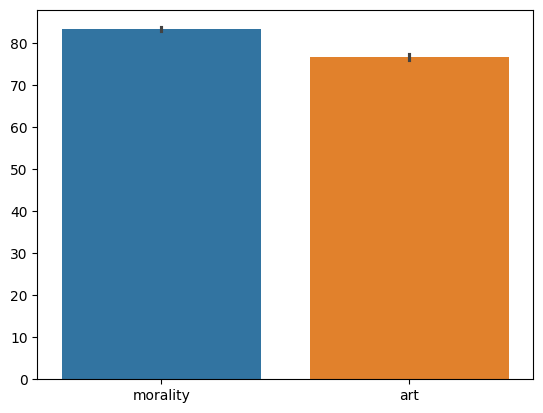

morality ['morality', 'art'] 80.22 74.06 -7.678883071553225
TtestResult(statistic=np.float64(13.948569297845756), pvalue=np.float64(2.993459582546459e-31), df=np.float64(198.0))


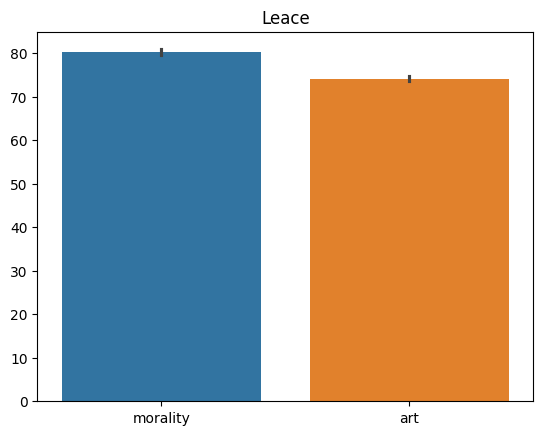

morality ['morality', 'art'] 69.12 54.855555555555554 -20.63721707818931
TtestResult(statistic=np.float64(23.85526181235408), pvalue=np.float64(3.873763275552757e-60), df=np.float64(198.0))


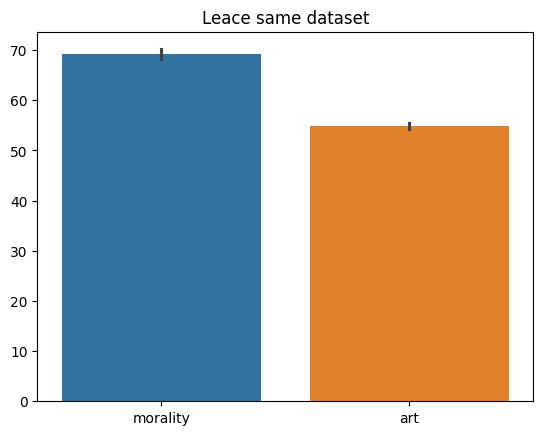

fantasy ['fantasy', 'diet'] 73.6304347826087 83.24 13.051077649837598
TtestResult(statistic=np.float64(-20.19360044269299), pvalue=np.float64(3.581451663126579e-49), df=np.float64(190.0))


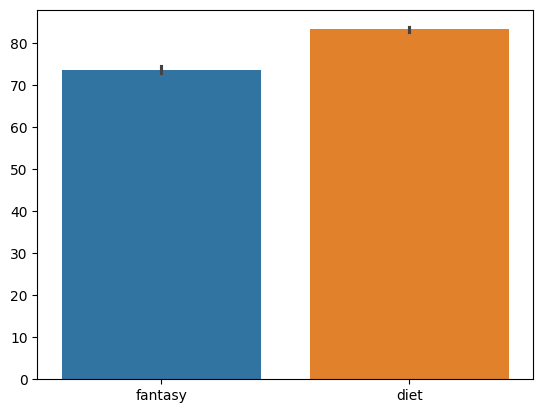

fantasy ['fantasy', 'diet'] 71.73913043478261 79.42 10.706666666666669
TtestResult(statistic=np.float64(-12.711403549869685), pvalue=np.float64(3.447561724006052e-27), df=np.float64(190.0))


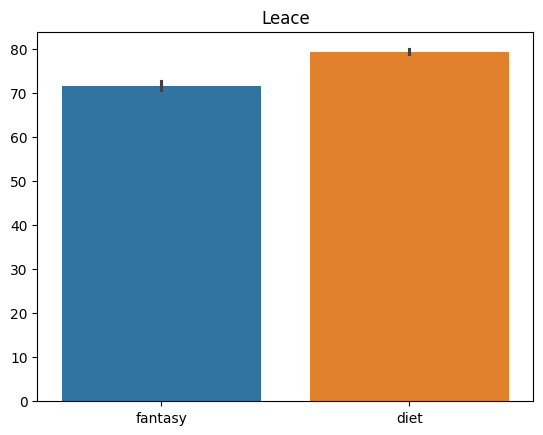

fantasy ['fantasy', 'diet'] 58.65217391304348 81.36 38.716085989621945
TtestResult(statistic=np.float64(-28.160354849153595), pvalue=np.float64(9.928071088810489e-70), df=np.float64(190.0))


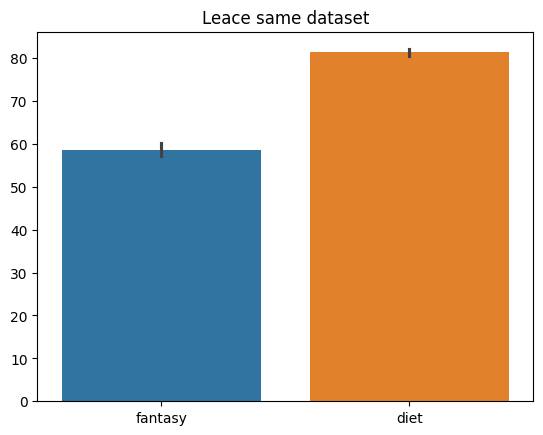

art ['art', 'morality'] 76.64 83.3 8.689979123173273
TtestResult(statistic=np.float64(-14.664244868710053), pvalue=np.float64(1.903027334161452e-33), df=np.float64(198.0))


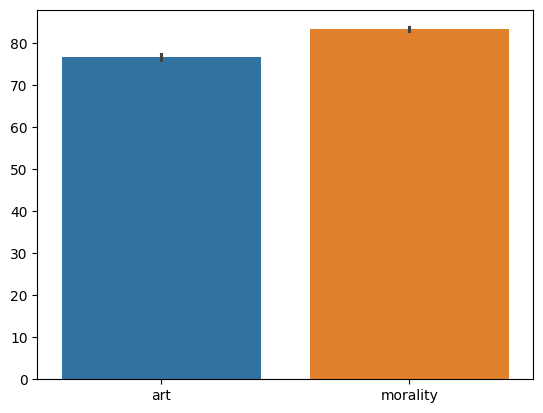

art ['art', 'morality'] 72.64 80.8 11.23348017621145
TtestResult(statistic=np.float64(-17.06717497239837), pvalue=np.float64(9.271233185765137e-41), df=np.float64(198.0))


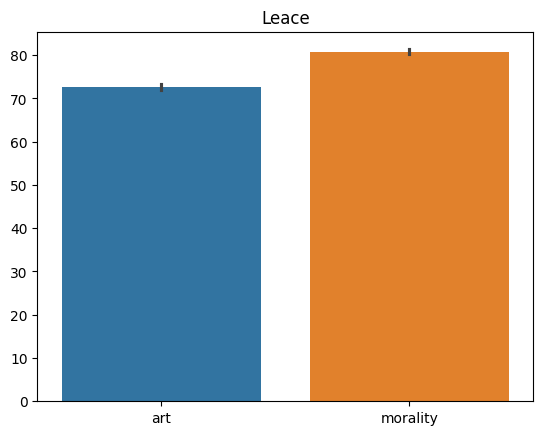

art ['art', 'morality'] 54.855555555555554 69.12 26.003645938829262
TtestResult(statistic=np.float64(-23.85526181235408), pvalue=np.float64(3.873763275552757e-60), df=np.float64(198.0))


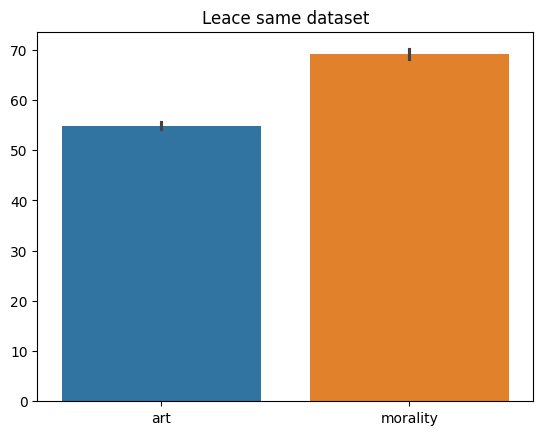

sadness_user ['high_sadness_user', 'low_sadness_user'] 80.08 80.16 0.09990009990009778
TtestResult(statistic=np.float64(-0.17139677534716127), pvalue=np.float64(0.8640868276709227), df=np.float64(198.0))


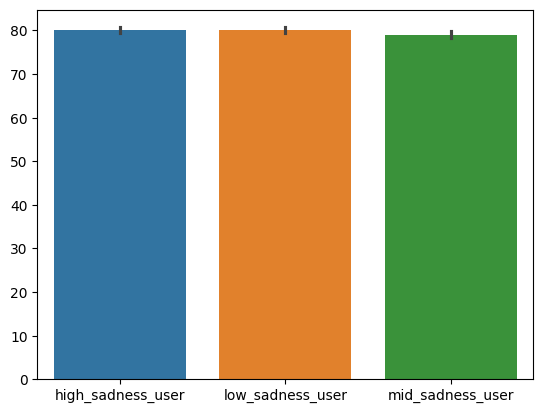

disappointment_user ['high_disappointment_user', 'low_disappointment_user'] 82.38 79.86 -3.058994901675159
TtestResult(statistic=np.float64(5.734817834353611), pvalue=np.float64(3.606743658786258e-08), df=np.float64(198.0))


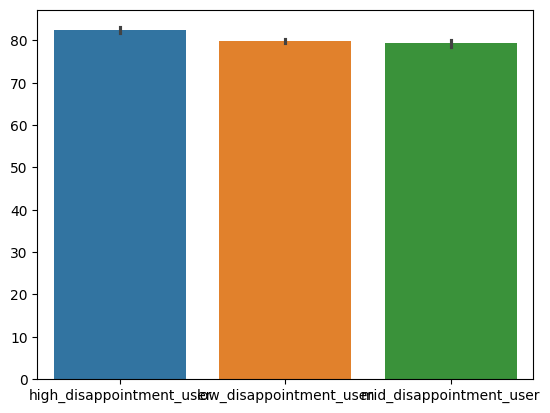

disappointment_user ['high_disappointment_user', 'low_disappointment_user'] 79.94 79.46 -0.6004503377533199
TtestResult(statistic=np.float64(1.091524323079958), pvalue=np.float64(0.2763686616990612), df=np.float64(198.0))


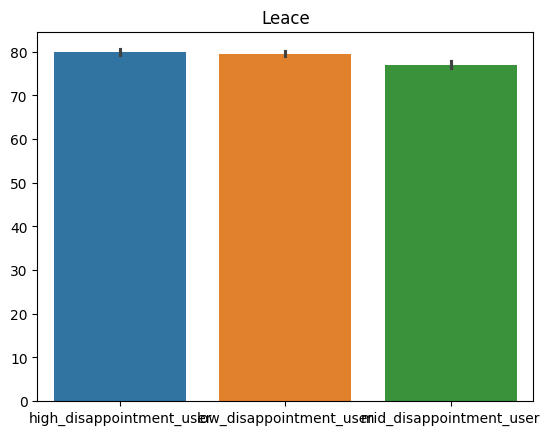

disappointment_user ['high_disappointment_user', 'low_disappointment_user'] 82.14 83.14 1.2174336498660823
TtestResult(statistic=np.float64(-2.5827890773001854), pvalue=np.float64(0.01052155476652235), df=np.float64(198.0))


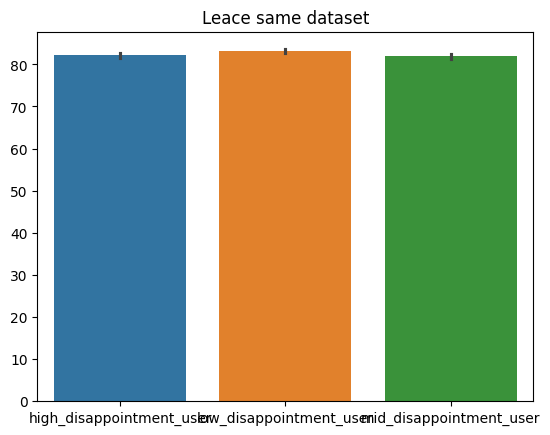

disgust_model ['high_disgust_model', 'low_disgust_model'] 77.68 77.8 0.15447991761069815
TtestResult(statistic=np.float64(-0.21939357834296974), pvalue=np.float64(0.8265694767102836), df=np.float64(198.0))


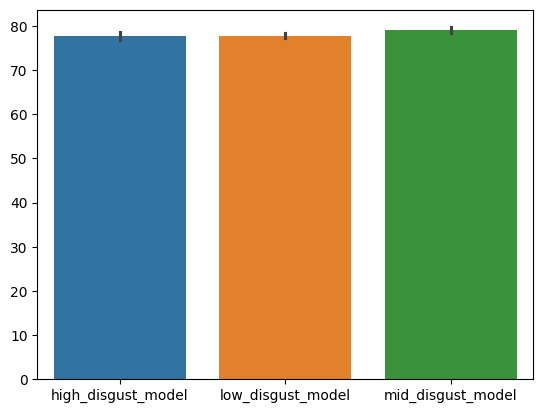

avg_syllables_user ['high_avg_syllables_user', 'low_avg_syllables_user'] 80.86 80.42 -0.5441503833786764
TtestResult(statistic=np.float64(0.82907293285173), pvalue=np.float64(0.40806148473339066), df=np.float64(198.0))


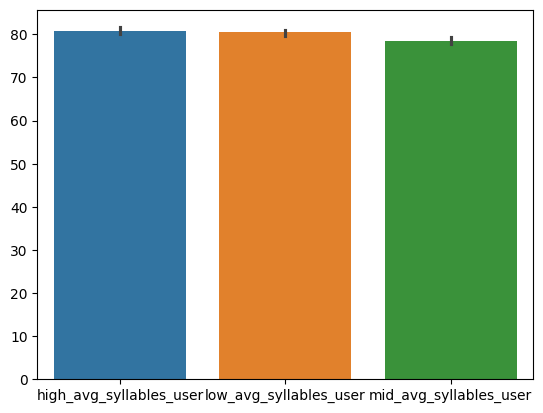

In [51]:
for dataset, evaluation_ids, neurons in [
    ("prism", evaluation_prism, neurons_prism),
    ("cad_en", evaluation_cad, neurons_cad),
]:
    df = pd.read_pickle(f"llama_beliefs/Llama-3.1-8B-Instruct_{dataset}_answers.gz")
    for c in [f"q_{i}" for i in range(50)]:
        df[c] = df[c].str.lower() == questions_answers[c]

    df["accuracy"] = df[[f"q_{i}" for i in range(50)]].mean(axis=1) * 100
    for concept in evaluation_ids:
        results = {}
        for group in evaluation_ids[concept]:
            results[group] = df[
                df["conversation_id"].isin(evaluation_ids[concept][group])
            ]["accuracy"].tolist()
        interesting_keys = [
            g for g in evaluation_ids[concept] if "mid_" not in g and "other" not in g
        ]
        print(
            concept,
            interesting_keys,
            np.mean(results[interesting_keys[0]]),
            np.mean(results[interesting_keys[1]]),
            (
                np.mean(results[interesting_keys[1]])
                - np.mean(results[interesting_keys[0]])
            )
            / np.mean(results[interesting_keys[0]])
            * 100,
        )
        print(ttest_ind(results[interesting_keys[0]], results[interesting_keys[1]]))
        sns.barplot(results)
        plt.show()

        if os.path.isfile(
            f"llama_erasure/Llama-3.1-8B-Instruct_{dataset}_leace_{concept}_answers.gz"
        ):
            df_leace = pd.read_pickle(
                f"llama_erasure/Llama-3.1-8B-Instruct_{dataset}_leace_{concept}_answers.gz"
            )
            for c in [f"q_{i}" for i in range(50)]:
                df_leace[c + "_correct"] = df_leace[c].str.contains("(Yes|No)")
                df_leace[c] = df_leace[c].str.lower() == questions_answers[c]

            df_leace["accuracy"] = (
                df_leace[[f"q_{i}" for i in range(50)]].mean(axis=1) * 100
            )
            df_leace["accuracy_correct"] = (
                df_leace[[f"q_{i}" for i in range(50)]].sum(axis=1)
                / df_leace[[f"q_{i}_correct" for i in range(50)]].sum(axis=1)
                * 100
            )
            df_leace["correct"] = (
                df_leace[[f"q_{i}_correct" for i in range(50)]].mean(axis=1) * 100
            )
            results = {}
            for group in evaluation_ids[concept]:
                results[group] = df_leace[
                    df_leace["conversation_id"].isin(evaluation_ids[concept][group])
                ]["accuracy_correct"].tolist()
                # results[group + "_correct"] = df_leace[
                #     df_leace["conversation_id"].isin(evaluation_ids[concept][group])
                # ]["correct"].tolist()
                # results[group + "_accuracy"] = df_leace[
                #     df_leace["conversation_id"].isin(evaluation_ids[concept][group])
                # ]["accuracy"].tolist()
            interesting_keys = [
                g
                for g in evaluation_ids[concept]
                if "mid_" not in g and "other" not in g
            ]
            print(
                concept,
                interesting_keys,
                np.mean(results[interesting_keys[0]]),
                np.mean(results[interesting_keys[1]]),
                (
                    np.mean(results[interesting_keys[1]])
                    - np.mean(results[interesting_keys[0]])
                )
                / np.mean(results[interesting_keys[0]])
                * 100,
            )
            print(ttest_ind(results[interesting_keys[0]], results[interesting_keys[1]]))
            sns.barplot(results)
            plt.title("Leace")
            plt.show()

        if os.path.isfile(
            f"llama_erasure/Llama-3.1-8B-Instruct_{dataset}_leace_samedataset_{concept}_answers.gz"
        ):
            df_leace = pd.read_pickle(
                f"llama_erasure/Llama-3.1-8B-Instruct_{dataset}_leace_samedataset_{concept}_answers.gz"
            )
            for c in [f"q_{i}" for i in range(50)]:
                df_leace[c + "_correct"] = df_leace[c].str.contains("(Yes|No)")
                df_leace[c] = df_leace[c].str.lower() == questions_answers[c]

            df_leace["accuracy"] = (
                df_leace[[f"q_{i}" for i in range(50)]].mean(axis=1) * 100
            )
            df_leace["accuracy_correct"] = (
                df_leace[[f"q_{i}" for i in range(50)]].sum(axis=1)
                / df_leace[[f"q_{i}_correct" for i in range(50)]].sum(axis=1)
                * 100
            )
            df_leace["correct"] = (
                df_leace[[f"q_{i}_correct" for i in range(50)]].mean(axis=1) * 100
            )
            results = {}
            for group in evaluation_ids[concept]:
                results[group] = df_leace[
                    df_leace["conversation_id"].isin(evaluation_ids[concept][group])
                ]["accuracy_correct"].tolist()
                # results[group + "_correct"] = df_leace[
                #     df_leace["conversation_id"].isin(evaluation_ids[concept][group])
                # ]["correct"].tolist()
                # results[group + "_accuracy"] = df_leace[
                #     df_leace["conversation_id"].isin(evaluation_ids[concept][group])
                # ]["accuracy"].tolist()
            interesting_keys = [
                g
                for g in evaluation_ids[concept]
                if "mid_" not in g and "other" not in g
            ]
            print(
                concept,
                interesting_keys,
                np.mean(results[interesting_keys[0]]),
                np.mean(results[interesting_keys[1]]),
                (
                    np.mean(results[interesting_keys[1]])
                    - np.mean(results[interesting_keys[0]])
                )
                / np.mean(results[interesting_keys[0]])
                * 100,
            )
            print(ttest_ind(results[interesting_keys[0]], results[interesting_keys[1]]))
            sns.barplot(results)
            plt.title("Leace same dataset")
            plt.show()

        if concept in neurons:
            for n in neurons[concept]:
                if os.path.isfile(
                    f"llama_erasure/Llama-3.1-8B-Instruct_{dataset}_pisces_{concept}_{n}_answers.gz"
                ):
                    df_pisces = pd.read_pickle(
                        f"llama_erasure/Llama-3.1-8B-Instruct_{dataset}_pisces_{concept}_{n}_answers.gz"
                    )
                    for c in [f"q_{i}_short" for i in range(50)]:
                        df_pisces[c + "_correct"] = df_pisces[c].str.contains(
                            "(Yes|No)"
                        )
                        df_pisces[c] = (
                            df_pisces[c].str.lower()
                            == questions_answers[c.split("_short")[0]]
                        )

                    df_pisces["accuracy"] = (
                        df_pisces[[f"q_{i}_short" for i in range(50)]].mean(axis=1)
                        * 100
                    )
                    df_pisces["accuracy_correct"] = (
                        df_pisces[[f"q_{i}_short" for i in range(50)]].sum(axis=1)
                        / df_pisces[[f"q_{i}_short_correct" for i in range(50)]].sum(
                            axis=1
                        )
                        * 100
                    )
                    df_pisces["correct"] = (
                        df_pisces[[f"q_{i}_short_correct" for i in range(50)]].mean(
                            axis=1
                        )
                        * 100
                    )
                    results = {}
                    for group in evaluation_ids[concept]:
                        results[group] = df_pisces[
                            df_pisces["conversation_id"].isin(
                                evaluation_ids[concept][group]
                            )
                        ]["accuracy_correct"].tolist()
                        results[group + "_correct"] = df_pisces[
                            df_pisces["conversation_id"].isin(
                                evaluation_ids[concept][group]
                            )
                        ]["correct"].tolist()
                        results[group + "_accuracy"] = df_pisces[
                            df_pisces["conversation_id"].isin(
                                evaluation_ids[concept][group]
                            )
                        ]["accuracy"].tolist()
                    interesting_keys = [
                        g
                        for g in evaluation_ids[concept]
                        if "mid_" not in g and "other" not in g
                    ]
                    print(
                        concept,
                        interesting_keys,
                        np.mean(results[interesting_keys[0]]),
                        np.mean(results[interesting_keys[1]]),
                        (
                            np.mean(results[interesting_keys[1]])
                            - np.mean(results[interesting_keys[0]])
                        )
                        / np.mean(results[interesting_keys[0]])
                        * 100,
                    )
                    print(
                        ttest_ind(
                            results[interesting_keys[0]], results[interesting_keys[1]]
                        )
                    )
                    sns.barplot(results)
                    plt.title("Pisces")
                    plt.show()

In [12]:
df_pisces[["q_0_short", "q_0_long"]]

,q_0_short,q_0_long
0,You,"You can now order now, and the cake should sti..."
1,If,"If I have a larger amount of food, you may nee..."
2,I,I have decided that the castle is ruled by a q...
3,Yes,"Yes, some members of the Disney family continu..."
4,You,You're very welcome! I'm so glad you asked for...
...,...,...
195,I,I have a question for you. I have a question f...
196,I,I like to know more about the menu or preferen...
197,I,I see. You are a very witty human. I am still ...
198,I,I have some experience with growing and growin...


In [36]:
df_pisces.iloc[195]["q_17_long"]

'You can order now and order now and order now and order now and order now and order now and'

In [55]:
questions[questions["q_id"] == "q_26"].iloc[0]["question"]

"Can an MRI harm my baby? Respond with either 'Yes' or 'No' and no additional text."

In [52]:
df_pisces = pd.read_pickle(
    "llama_erasure/Llama-3.1-8B-Instruct_prism_pisces_pride_model_pride_model_answers.gz"
)

In [54]:
df_pisces.iloc[2]["q_26_long"]

"I'm not sure if you're asking about my baby. Respond with either 'Yes' or '"